# 27_01 RUL 기반 고장 임박 문제

In [1]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

✅ 환경 설정 완료! 현재 적용된 폰트: ['AppleGothic']


## 라이브러리 임포트와 첫 불러오기
- 내내 다룰 데이터를 컴퓨터로 불러와 첫인사를 나누는 단계
- pandas를 불러오고 cmapss_fd001_sample.csv를 표로 읽어 첫 모습 확인

### 불러오기 코드
pandas를 pd로 부르고 read_csv로 파일을 df라는 표에 담기

In [ ]:
# 코드
df = pd.read_csv('data/27_cmapss_fd001_sample.csv')

,unit_id,cycle,sensor_2,sensor_3,sensor_4,sensor_7,sensor_11,sensor_15,RUL
0,1,1,641.533,1588.007,1405.656,553.023,46.875,8.405,146
1,1,2,641.861,1584.947,1394.917,554.436,47.396,8.403,145
2,1,3,642.513,1586.896,1394.908,554.178,46.963,8.436,144
3,1,4,641.986,1584.301,1396.013,554.601,47.165,8.384,143
4,1,5,641.853,1587.186,1402.331,554.193,47.313,8.487,142


### 첫 모습 확인
head로 첫 5행을, shape로 행과 열 개수를 확인

In [3]:
# 코드
print(df.shape)
df.head(5)

(3614, 9)


,unit_id,cycle,sensor_2,sensor_3,sensor_4,sensor_7,sensor_11,sensor_15,RUL
0,1,1,641.533,1588.007,1405.656,553.023,46.875,8.405,146
1,1,2,641.861,1584.947,1394.917,554.436,47.396,8.403,145
2,1,3,642.513,1586.896,1394.908,554.178,46.963,8.436,144
3,1,4,641.986,1584.301,1396.013,554.601,47.165,8.384,143
4,1,5,641.853,1587.186,1402.331,554.193,47.313,8.487,142


### 데이터 크기 점검
shape로 전체 행과 열의 개수를 다시 확인해 규모 감을 잡기

In [4]:
# 코드
print(df.shape)

(3614, 9)


### 컬럼 이름 확인
분석 전 데이터가 어떻게 생겼는지 살펴보는 일은 길 떠나기 전 지도 확인

In [ ]:
# 코드
print(df.columns)

<class 'pandas.DataFrame'>
RangeIndex: 3614 entries, 0 to 3613
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   unit_id    3614 non-null   int64  
 1   cycle      3614 non-null   int64  
 2   sensor_2   3614 non-null   float64
 3   sensor_3   3614 non-null   float64
 4   sensor_4   3614 non-null   float64
 5   sensor_7   3614 non-null   float64
 6   sensor_11  3614 non-null   float64
 7   sensor_15  3614 non-null   float64
 8   RUL        3614 non-null   int64  
dtypes: float64(6), int64(3)
memory usage: 254.2 KB
Index(['unit_id', 'cycle', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7',
       'sensor_11', 'sensor_15', 'RUL'],
      dtype='str')


### 자료형과 결측 요약
info는 각 컬럼의 자료형과 값 개수를 요약 — 결측 단서까지 한눈에

In [7]:
# 코드
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3614 entries, 0 to 3613
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   unit_id    3614 non-null   int64  
 1   cycle      3614 non-null   int64  
 2   sensor_2   3614 non-null   float64
 3   sensor_3   3614 non-null   float64
 4   sensor_4   3614 non-null   float64
 5   sensor_7   3614 non-null   float64
 6   sensor_11  3614 non-null   float64
 7   sensor_15  3614 non-null   float64
 8   RUL        3614 non-null   int64  
dtypes: float64(6), int64(3)
memory usage: 254.2 KB


### 기초 통계 살펴보기
describe는 숫자 컬럼의 평균·최소·최대 같은 기초 통계 한눈에

In [8]:
# 코드
print(df.describe())

           unit_id        cycle     sensor_2     sensor_3     sensor_4  \
count  3614.000000  3614.000000  3614.000000  3614.000000  3614.000000   
mean     10.480077    91.842833   642.716319  1588.630193  1408.919402   
std       5.822356    53.855330     0.716776     4.817425     9.056095   
min       1.000000     1.000000   640.384000  1572.759000  1379.889000   
25%       5.000000    46.000000   642.179250  1585.314000  1402.384250   
50%      10.000000    91.000000   642.688000  1588.647500  1408.515500   
75%      16.000000   136.000000   643.237000  1591.869250  1415.269000   
max      20.000000   215.000000   645.006000  1604.662000  1437.818000   

          sensor_7    sensor_11    sensor_15          RUL  
count  3614.000000  3614.000000  3614.000000  3614.000000  
mean    553.124533    47.559457     8.473617    90.842833  
std       0.832421     0.366593     0.067264    53.855330  
min     550.291000    46.447000     8.285000     0.000000  
25%     552.530250    47.285250  

### 마지막 행 확인
tail로 마지막 5행을 보고 데이터가 끝까지 잘 들어왔는지 확인

In [9]:
# 코드
df.tail(5)

,unit_id,cycle,sensor_2,sensor_3,sensor_4,sensor_7,sensor_11,sensor_15,RUL
3609,20,175,643.919,1592.113,1429.256,552.014,47.574,8.533,4
3610,20,176,643.451,1595.543,1415.133,551.931,47.743,8.576,3
3611,20,177,643.936,1599.696,1423.106,551.428,48.458,8.570,2
3612,20,178,644.133,1591.473,1422.361,551.418,48.173,8.611,1
3613,20,179,643.577,1591.796,1424.141,551.387,47.721,8.594,0


### 설비 대수 세기
nunique는 서로 다른 값의 개수 — unit_id에 적용해 설비 대수 확인

In [10]:
# 코드
df['unit_id'].nunique()

20

## 결측치와 센서 범위 점검
- 빠진 값과 센서마다 값 크기 차이 — 분석 전 빈틈 점검부터
- 컬럼별 결측치 개수를 세고 센서값 범위를 비교
- 좋은 분석은 데이터의 빈틈을 먼저 점검하는 데서 시작


### 결측치 세기
isna와 sum을 이어 쓰면 컬럼별 결측치 개수 한눈에

In [14]:
# 코드
df.isna().sum()

unit_id      0
cycle        0
sensor_2     0
sensor_3     0
sensor_4     0
sensor_7     0
sensor_11    0
sensor_15    0
RUL          0
dtype: int64

### 한 센서 분포 보기
특정 센서 하나에 describe를 적용해 값의 분포를 자세히 보기

In [15]:
# 코드
df['sensor_2'].describe()

count    3614.000000
mean      642.716319
std         0.716776
min       640.384000
25%       642.179250
50%       642.688000
75%       643.237000
max       645.006000
Name: sensor_2, dtype: float64

## 한 설비의 일생 따라가기
- 1번 엔진 하나만 떼어 내어 처음부터 고장까지 행을 따라 읽기
- 설비 한 대만 골라 cycle 순서로 RUL과 센서 변화 관찰
- 전체가 아니라 1번 엔진 하나에 집중

### 여러 센서 평균 비교
센서 여러 개의 평균을 한 번에 비교

In [16]:
# 코드
df[['sensor_2', 'sensor_4', 'sensor_11']].mean()

sensor_2      642.716319
sensor_4     1408.919402
sensor_11      47.559457
dtype: float64

### 한 설비만 골라내기
unit_id가 1인 행만 골라 unit1에 담고 행 수 확인

In [18]:
# 코드
len(df[df['unit_id'] == 1])

147

### 시작과 끝의 RUL 비교
이 설비의 시작 부분과 끝부분 RUL을 한눈에 비교

In [22]:
# 코드
unit1 = df[df['unit_id'] == 1]
print(unit1[['cycle', 'RUL']].head())
print(unit1[['cycle', 'RUL']].tail())

   cycle  RUL
0      1  146
1      2  145
2      3  144
3      4  143
4      5  142
     cycle  RUL
142    143    4
143    144    3
144    145    2
145    146    1
146    147    0


### RUL 변화 그래프 그리기
cycle에 따른 RUL 변화를 선 그래프로 그려 우하향 직선 확인

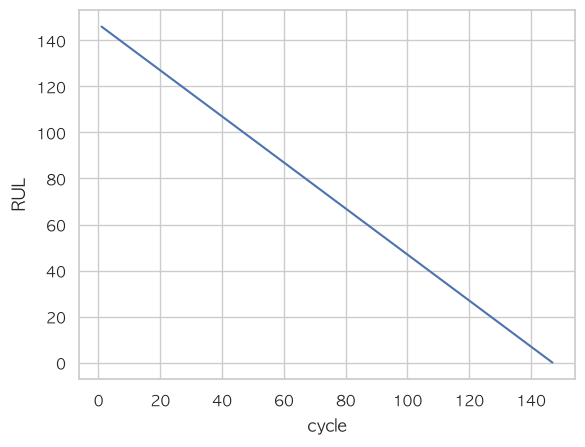

In [25]:
# 코드
plt.plot(unit1['cycle'], unit1['RUL'])
plt.xlabel('cycle')
plt.ylabel('RUL')
plt.show()

## 두 설비의 수명 비교
- 설비끼리는 cycle만으로 비교 불가 — 두 설비를 나란히 두고 직접 확인
- 두 설비의 최대 cycle 비교 + 같은 cycle에서 상태 차이
- 설비마다 고장까지 버티는 cycle 수가 다름을 직접 확인

### 설비별 수명 길이 구하기
groupby로 설비별 최대 cycle(=수명 길이)을 구하고 정렬


In [26]:
# 설비별 가장 큰 cycle = 수명 길이
life = df.groupby('unit_id')['cycle'].max()

# 오래 산 설비부터 일찍 고장난 설비까지 한눈에 보기
life.sort_values()

unit_id
1     147
12    149
9     161
10    163
15    164
13    168
18    172
7     173
6     177
14    177
17    177
20    179
11    187
3     197
5     198
8     198
2     202
19    205
4     205
16    215
Name: cycle, dtype: int64

### 같은 cycle에서 RUL 비교
두 설비의 같은 50 cycle 시점을 각각 골라 RUL 비교

In [29]:
# 1번 엔진의 50 cycle 시점
df[(df['unit_id'] == 1) & (df['cycle'] == 50)]

,unit_id,cycle,sensor_2,sensor_3,sensor_4,sensor_7,sensor_11,sensor_15,RUL
49,1,50,642.436,1587.969,1402.133,552.685,47.461,8.505,97


In [30]:
# 2번 엔진의 50 cycle 시점
df[(df['unit_id'] == 2) & (df['cycle'] == 50)]

,unit_id,cycle,sensor_2,sensor_3,sensor_4,sensor_7,sensor_11,sensor_15,RUL
196,2,50,642.289,1587.573,1405.214,553.069,47.525,8.39,152


## 비교에서 얻는 교훈
- 같은 cycle이라도 설비마다 RUL이 다름
- cycle만으로는 설비끼리 직접 비교할 수 없음